In [1]:
import os
import re
import imagehash
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import shutil
import torch
import torch.nn as nn
import torch.optim as optim  

from pathlib import Path
from PIL import Image
from collections import Counter, defaultdict 
from tqdm.auto import tqdm
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import models, transforms
from PIL import Image
from sklearn.model_selection import GroupShuffleSplit

from wakepy import keep
with keep.running(on_fail='warn'):

In [2]:
ROOT = Path("Classes")

# find all paths
files = [file for file in ROOT.rglob("*") if file.is_file() and not file.name.startswith(".")]

In [3]:
# check file extension
extensions = [file.suffix.lower() for file in files]
ext_counts = pd.Series(extensions).value_counts()
pd.set_option('display.max_colwidth', 80)
print("Top 10 file extensions:")
print(ext_counts.head(10))

Top 10 file extensions:
.jpg     45591
.jpeg    45163
.png     11959
Name: count, dtype: int64


In [4]:
data_list = [] 

for file in files:
    try:
        with Image.open(file) as img:
            w, h = img.size
            data_list.append([str(file), 
                              len(file.relative_to(ROOT).parts),
                              file.stem,
                              file.suffix.lstrip("."), 
                              w, 
                              h
                             ])
    except Exception as e:
        continue

# convert list to DataFrame
data = pd.DataFrame(data_list, columns=["file_path", "depth", "file_name", "file_ext", "width", "height"])

In [5]:
data.shape

(102713, 6)

In [6]:
data.head()

,file_path,depth,file_name,file_ext,width,height
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102713 entries, 0 to 102712
Data columns (total 6 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   file_path  102713 non-null  object
 1   depth      102713 non-null  int64 
 2   file_name  102713 non-null  object
 3   file_ext   102713 non-null  object
 4   width      102713 non-null  int64 
 5   height     102713 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 4.7+ MB


In [8]:
data.describe()

,depth,width,height
count,102713.000000,102713.000000,102713.000000
mean,3.065367,462.774741,429.986136
std,0.247173,168.250166,122.454167
min,3.000000,90.000000,90.000000
25%,3.000000,375.000000,374.000000
50%,3.000000,500.000000,500.000000
75%,3.000000,500.000000,500.000000
max,4.000000,1280.000000,1024.000000


#### Depth shows the number of folders away a file is from your starting point (ROOT)

In [9]:
# checking the 
depths = []
for f in ROOT.rglob("*"):
    if f.is_file():
        depths.append(len(f.relative_to(ROOT).parts))

print("Depths:", set(depths))
for d in sorted(set(depths)):
    print(f"Depth {d}: {depths.count(d)} files")

Depths: {3, 4}
Depth 3: 95999 files
Depth 4: 6714 files


In [10]:
print("\nSample files with depth 4:")
data[data['depth'] == 3].head()


Sample files with depth 4:


,file_path,depth,file_name,file_ext,width,height
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512


In [11]:
print("\nSample files with depth 4:")
data[data['depth'] == 4].head()


Sample files with depth 4:


,file_path,depth,file_name,file_ext,width,height
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575


#### aspeact ratio - consistency to prevent the images being stretched or squished.
#### megapixel - image quality control(not blurry) and check hardware limits
#### orientation - landscape vs. portrait

In [12]:
# checking the images
data["aspect_ratio"] = data["width"] / data["height"]
data["megapixels"] = (data["width"] * data["height"]) / 1_000_000
data["orientation"] = np.where(data["aspect_ratio"] > 1, "landscape", np.where(data["aspect_ratio"] < 1, "portrait", "square"))

# some AI models only detect square image
square_images = data[data["orientation"] == "square"]
print(f"1. Square images: {len(square_images)}")

# find high-resolution images
high_res = data[data["megapixels"] > 1.0]
print(f"\n2. High-res images (>1MP): {len(high_res)}")

# check orientation distribution
orientation_counts = data["orientation"].value_counts()
print("\n3. Orientation distribution:")
print(orientation_counts)

# find extreme aspect ratios 
extreme = data[(data["aspect_ratio"] > 3) | (data["aspect_ratio"] < 0.33)]
print(f"\n4. Extreme aspect ratios: {len(extreme)}")

1. Square images: 8648

2. High-res images (>1MP): 434

3. Orientation distribution:
orientation
landscape    55282
portrait     38783
square        8648
Name: count, dtype: int64

4. Extreme aspect ratios: 13


In [13]:
# check for unique depths
unique_depths = sorted(set(len(f.relative_to(ROOT).parts) for f in files))
print(f"Unique depth levels found: {unique_depths}")

Unique depth levels found: [3, 4]


In [14]:
# only check depth 3 and 4 and count
depth3_count = sum(1 for f in files if len(f.relative_to(ROOT).parts) == 3)
depth4_count = sum(1 for f in files if len(f.relative_to(ROOT).parts) == 4)

print(f"Depth 3 files: {depth3_count:,} ({depth3_count/len(files)*100:.1f}%)")
print(f"Depth 4 files: {depth4_count:,} ({depth4_count/len(files)*100:.1f}%)")

Depth 3 files: 95,999 (93.5%)
Depth 4 files: 6,714 (6.5%)


In [15]:
data[data['depth'] == 3]['file_path'].apply(lambda x: x.split('/')[:-1]).value_counts().head()

file_path
[Classes, poisonous, Xanthoria parietina]               5837
[Classes, conditionally_edible, Fomes fomentarius]      5254
[Classes, conditionally_edible, Fomitopsis pinicola]    5096
[Classes, poisonous, Amanita muscaria]                  4258
[Classes, conditionally_edible, Parmelia sulcata]       2654
Name: count, dtype: int64

In [16]:
data[data['depth'] == 4]['file_path'].apply(lambda x: x.split('/')[:-1]).value_counts().head()

file_path
[Classes, conditionally_edible, Mushrooms, Lactarius]      1563
[Classes, conditionally_edible, Mushrooms, Russula]        1148
[Classes, conditionally_edible, Mushrooms, Boletus]        1073
[Classes, conditionally_edible, Mushrooms, Cortinarius]     836
[Classes, conditionally_edible, Mushrooms, Amanita]         750
Name: count, dtype: int64

#### Find the series of species names
#### the path is split by '/', so take index 3 if depth is 4, or is index 2

In [17]:
raw_species = data.apply(lambda x: x['file_path'].split('/')[3] if x['depth'] == 4 else x['file_path'].split('/')[2], axis=1)

total = raw_species.nunique()
counts = raw_species.value_counts()

print(f"1. Total Unique Species Found: {total}")
print("\n2. *** Most 10 Species ***")
print(counts.head(10))
print("\n3. ***** Least 10 Species *****")
print(counts.tail(10))

1. Total Unique Species Found: 570

2. *** Most 10 Species ***
Xanthoria parietina      5837
Fomes fomentarius        5254
Fomitopsis pinicola      5096
Amanita muscaria         4258
Lactarius                3126
Parmelia sulcata         2654
Laetiporus sulphureus    2302
Russula                  2296
Hypogymnia physodes      2166
Boletus                  2146
Name: count, dtype: int64

3. ***** Least 10 Species *****
golden_bootleg         10
smoky_bracket          10
cedarwood_waxcap       10
oak_polypore           10
rooting_shank          10
cinnamon_bracket        9
orange_birch_bolete     8
devils_bolete           8
deadly_webcap           8
truffles                4
Name: count, dtype: int64


### Cleaning and organizing the data
#### - adding class and species column

In [18]:
data['class'] = data['file_path'].apply(lambda x: x.split('/')[1])
data['species'] = data.apply(lambda x: x['file_path'].split('/')[3] if x['depth'] == 4 else x['file_path'].split('/')[2], axis=1)

In [19]:
data[data['depth'] == 3].head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty


In [20]:
data[data['depth'] == 4].head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species
20454,Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg,4,251_J9uSJkkBULQ,jpg,800,531,1.506591,0.4248,landscape,conditionally_edible,Agaricus
20455,Classes/conditionally_edible/Mushrooms/Agaricus/357__w_XUQZMZEw.jpg,4,357__w_XUQZMZEw,jpg,800,600,1.333333,0.4800,landscape,conditionally_edible,Agaricus
20456,Classes/conditionally_edible/Mushrooms/Agaricus/374_Xap1L15Z8BM.jpg,4,374_Xap1L15Z8BM,jpg,777,600,1.295000,0.4662,landscape,conditionally_edible,Agaricus
20457,Classes/conditionally_edible/Mushrooms/Agaricus/442_bdfUNhioT1A.jpg,4,442_bdfUNhioT1A,jpg,800,600,1.333333,0.4800,landscape,conditionally_edible,Agaricus
20458,Classes/conditionally_edible/Mushrooms/Agaricus/092_YzaMvFvqkiM.jpg,4,092_YzaMvFvqkiM,jpg,800,575,1.391304,0.4600,landscape,conditionally_edible,Agaricus


In [21]:
species_per_class = data.groupby('class')['species'].nunique()
print("Unique Species per Class:\n", species_per_class)

Unique Species per Class:
 class
conditionally_edible    175
deadly                   40
edible                  160
poisonous               214
Name: species, dtype: int64


In [22]:
images_per_class_top = data.groupby(['class', 'species']).size().groupby('class').nlargest(5)
print("\nTop 5 Species per Class by Image Count:\n", images_per_class_top)


Top 5 Species per Class by Image Count:
 class                 class                 species              
conditionally_edible  conditionally_edible  Fomes fomentarius        5254
                                            Fomitopsis pinicola      5096
                                            Lactarius                3126
                                            Parmelia sulcata         2654
                                            Laetiporus sulphureus    2302
deadly                deadly                Amanita_arocheae           49
                                            Amanita_bisporigera        48
                                            Galerina_marginata         45
                                            Clitocybe_rivulosa         35
                                            Omphalotus_illudens        35
edible                edible                Cerioporus squamosus     1523
                                            Coprinus comatus         1309
    

In [23]:
print(data['class'].value_counts())
print("\nPercentages:")
print(data['class'].value_counts(normalize=True).mul(100).round(1))

class
conditionally_edible    61968
poisonous               21138
edible                  18417
deadly                   1190
Name: count, dtype: int64

Percentages:
class
conditionally_edible    60.3
poisonous               20.6
edible                  17.9
deadly                   1.2
Name: proportion, dtype: float64


### The Full Class Distribution shows imbalance of the dataset
####   - conditionally_edible has the most data (60.3%)
####   - deadly has the least data (1.2%)

- The graph shows the plot skews to the right.

- Imbalance data - when it is trained on naive model, it predicts well on dominating data, but not on least data.
If the model is used in the real world, it will be a very BIG issues - "deadly".


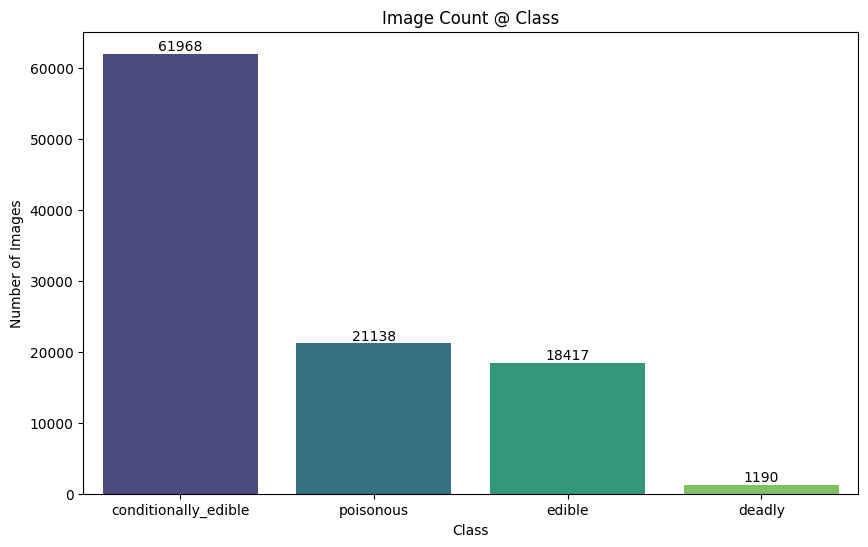

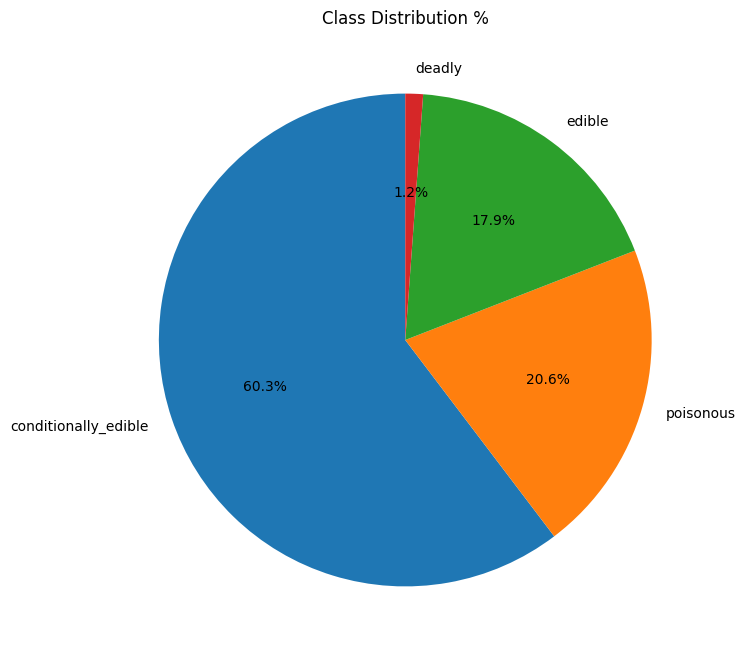

In [24]:
class_counts = data['class'].value_counts()
plt.figure(figsize=(10, 6))
sns.barplot(x=class_counts.index, y=class_counts.values, hue=class_counts.index, palette='viridis', legend=False)
plt.title('Image Count @ Class')
plt.ylabel('Number of Images')
plt.xlabel('Class')
for i, v in enumerate(class_counts.values):
    plt.text(i, v + 500, str(v), ha='center')
plt.show()

# Pie chart for proportions
plt.figure(figsize=(8, 8))
plt.pie(class_counts.values, labels=class_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Class Distribution %')
plt.show()


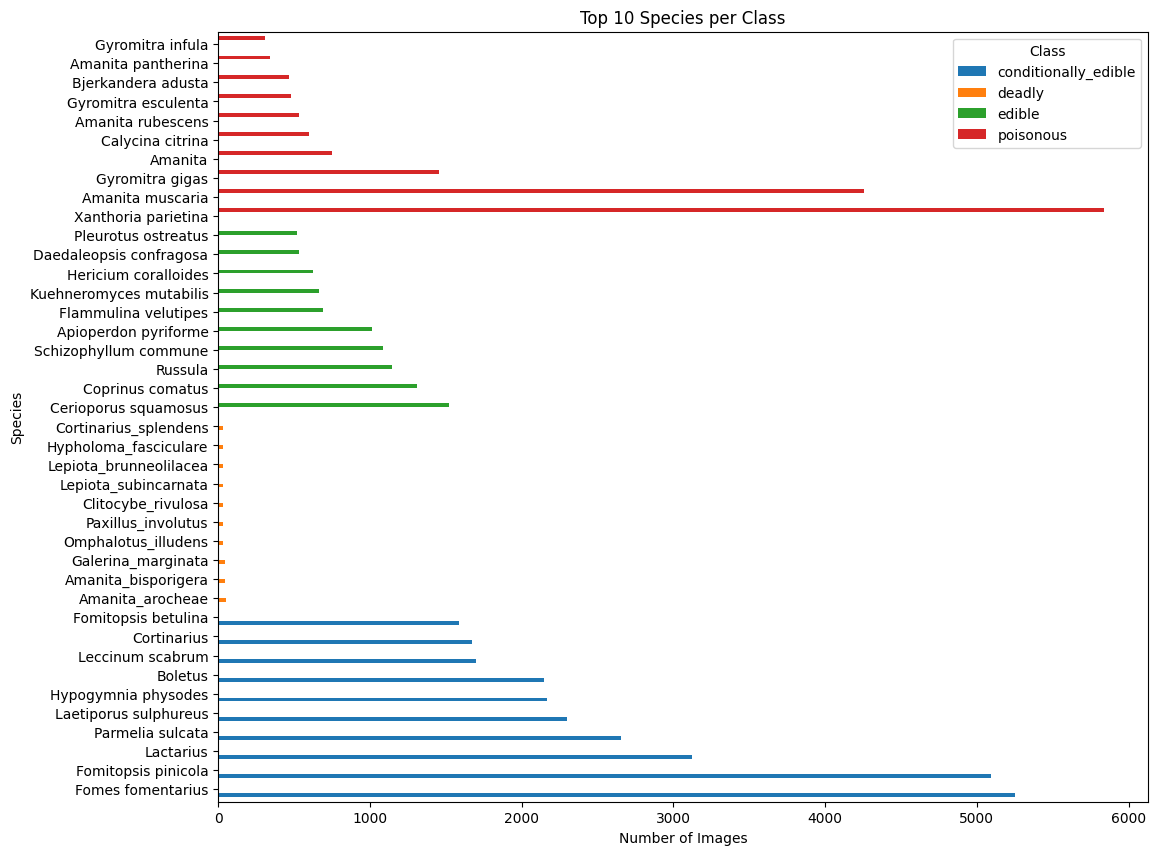

In [25]:
top_per_class = data.groupby('class')['species'].value_counts().groupby('class').head(10)

# Unstack for plotting
top_per_class.unstack(level=0).plot(kind='barh', figsize=(12, 10), width=0.8)
plt.title('Top 10 Species per Class')
plt.xlabel('Number of Images')
plt.ylabel('Species')
plt.legend(title='Class')
plt.show()

In [26]:
print(data['class'].value_counts())
print("\nPercentages:")
print(data['class'].value_counts(normalize=True).mul(100).round(1))

class
conditionally_edible    61968
poisonous               21138
edible                  18417
deadly                   1190
Name: count, dtype: int64

Percentages:
class
conditionally_edible    60.3
poisonous               20.6
edible                  17.9
deadly                   1.2
Name: proportion, dtype: float64


In [27]:
print("Species with ≤ 10 images:")
print(data['species'].value_counts()[lambda x: x <= 10].sort_values())

print("\nSpecies with ≥ 1000 images per class:")
print(data.groupby('class')['species'].value_counts().loc[lambda x: x >= 1000])

Species with ≤ 10 images:
species
truffles                    4
orange_birch_bolete         8
devils_bolete               8
deadly_webcap               8
cinnamon_bracket            9
hoof_fungus                10
leccinum_albostipitatum    10
golden_bootleg             10
smoky_bracket              10
cedarwood_waxcap           10
oak_polypore               10
rooting_shank              10
Name: count, dtype: int64

Species with ≥ 1000 images per class:
class                 species              
conditionally_edible  Fomes fomentarius        5254
                      Fomitopsis pinicola      5096
                      Lactarius                3126
                      Parmelia sulcata         2654
                      Laetiporus sulphureus    2302
                      Hypogymnia physodes      2166
                      Boletus                  2146
                      Leccinum scabrum         1697
                      Cortinarius              1672
                      Fomitop

In [28]:
data.groupby('class')[['width', 'height', 'megapixels']].agg(['mean','min','max','count'])

width                        height             \
                            mean  min   max  count        mean  min   max   
class                                                                       
conditionally_edible  495.722389  100  1280  61968  455.040553  100  1024   
deadly                201.892437  100   387   1190  174.136975  100   345   
edible                448.145572   90  1280  18417  414.169734   90   942   
poisonous             393.618507   94  1280  21138  384.720693   90  1024   

                            megapixels                             
                      count       mean       min       max  count  
class                                                              
conditionally_edible  61968   0.232204  0.010000  1.303552  61968  
deadly                 1190   0.037734  0.010000  0.050625   1190  
edible                18417   0.197820  0.008100  1.187840  18417  
poisonous             21138   0.163520  0.008742  1.286400  21138

### Check the number of files were skipped (i.e. could not be successfully read or processed)

In [29]:
total_files = len(files)
readable_images = len(data)
print(f"Skipped files: {total_files - readable_images:,} ({(total_files-readable_images)/total_files*100:.1f}%)")

Skipped files: 0 (0.0%)


In [30]:
counts = data['species'].value_counts()
min_threshold = 50  # Try 30 or 50
kept_species = counts[counts >= min_threshold].index
filtered_data = data[data['species'].isin(kept_species)]

print(f"Original: {len(data)} images, {counts.size} species")
print(f"Filtered (>= {min_threshold} images/species): {len(filtered_data)} images ({len(filtered_data)/len(data)*100:.1f}%), {len(kept_species)} species")
print(f"Class distribution after filter:\n{filtered_data['class'].value_counts()}")

Original: 102713 images, 570 species
Filtered (>= 50 images/species): 92990 images (90.5%), 147 species
Class distribution after filter:
class
conditionally_edible    60535
poisonous               16447
edible                  15707
deadly                    301
Name: count, dtype: int64


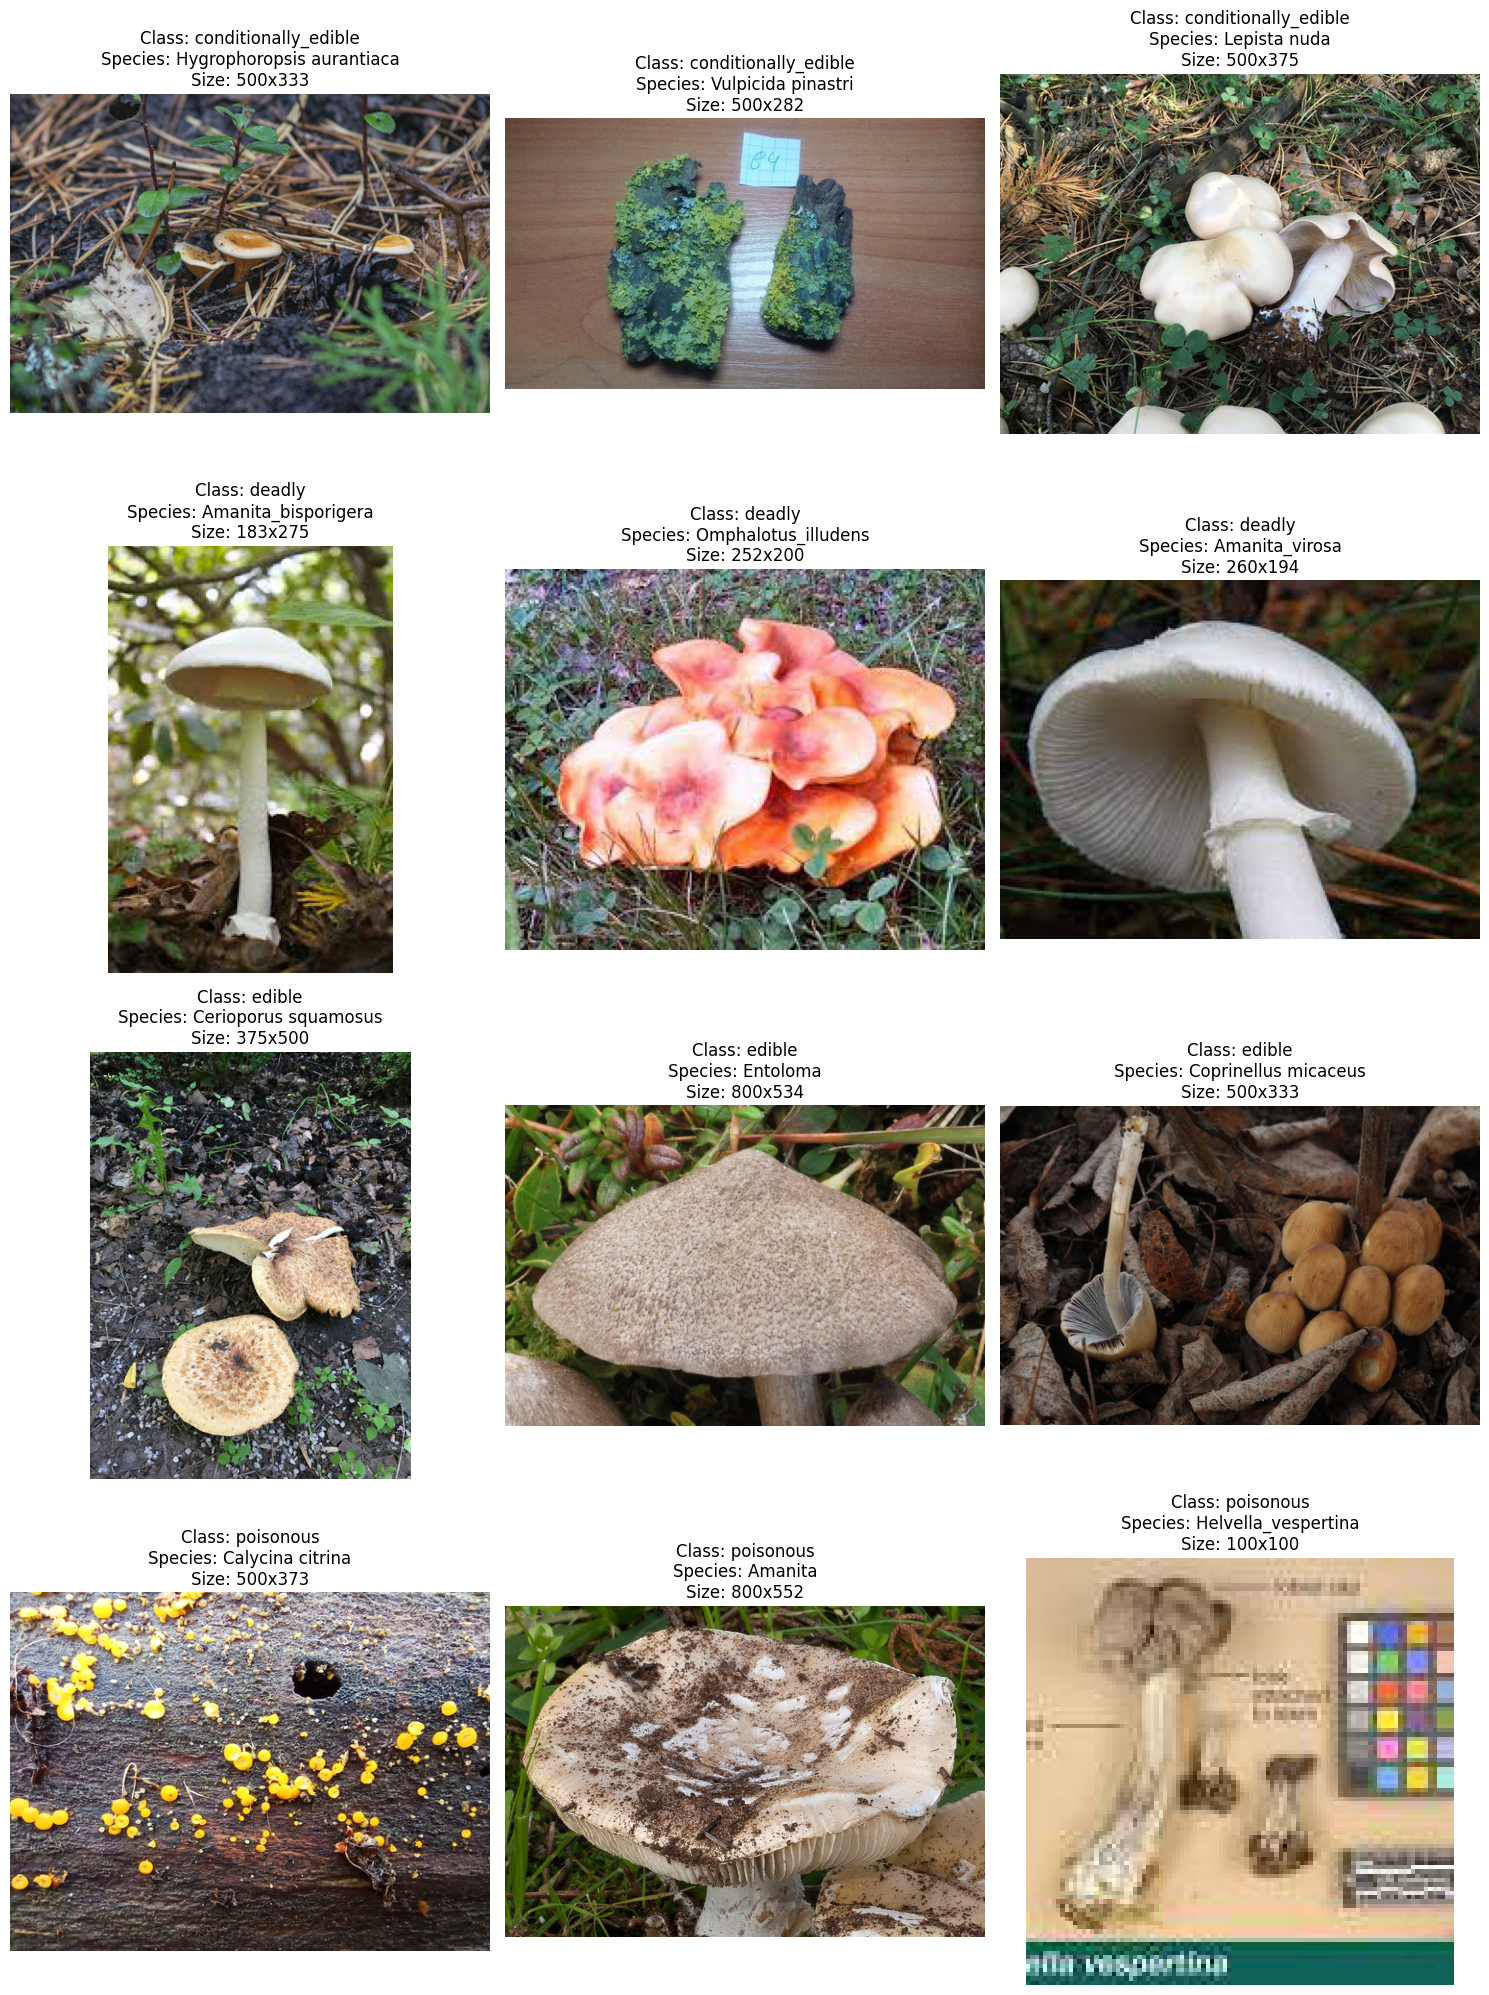

In [31]:
# sample per class
sample_images = data.groupby("class", group_keys=False).sample(3, random_state=42)
cols = 3
rows = (len(sample_images) + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
for ax, (_, row) in zip(axes.flatten(), sample_images.iterrows()):
    img = Image.open(row['file_path'])
    ax.imshow(img)
    ax.set_title(f"Class: {row['class']}\nSpecies: {row['species']}\nSize: {row['width']}x{row['height']}")
    ax.axis('off')
plt.tight_layout()
plt.show()

### De-Duplication of the dataframe
1. metadata filtering (width/height)
2. perceptual hasing (phash) - a very important step to clean large computer vision dataset quickly 
   - Using Phash to not break if the image was slightly resized or re-compressed
   - Focus on the structure of the image

#### Main goal: 
- shrinking - shrinks the image to 8 x 8
- grayscale - converts the image to grayscale
- DCT - applies DCT (discrete cosine Transform) - separate the image from different frequencies

#### Results:
- produces a 64-bit hash, which is then converted into a 16-character string (like a1b2c3d4e5f6g7h8)
- then keeps only the low freq, i.e. the structure
- discards the high freq, i.e. the detail and noise

#### Summary:
The results show a signigicant amount of duplicates.
Potential exact/very similar by size+dim: 22959 images.  There are several hash collisions...
Need to do some dataset cleaning.

After cleaning the dataset, the duplicate images will be saved in the duplicate folder.  And the clean dataset will be saved to the new dataframe called cleaned_data and then save it to a csv file called "cleaned_mushroom_dataset1".

In [32]:
# compute hashes - summarize each image's visual structure into a unique string of characters - gather info
# phash: shrink, grayscale, DCT, Low-frequency extraction

print("Start deduplication...")
hashes = []
for path in tqdm(data['file_path'], desc="Hashing images"):
    try:
        with Image.open(path) as img:
            hashes.append(str(imagehash.phash(img.convert('RGB'), hash_size=8)))
    except Exception as e:
        hashes.append(None)

data['phash'] = hashes
data = data.dropna(subset=['phash']).copy()

Start deduplication...


Hashing images:   0%|          | 0/102713 [00:00<?, ?it/s]

In [33]:
data.shape

(102711, 12)

In [34]:
# find exact duplicates by finding the indices of duplicates to be removed

to_remove = set()
hash_groups = data.groupby('phash')

for phash, group in tqdm(hash_groups, desc="Grouping exact matches"):
    if len(group) > 1:
        # Keep the one with the highest resolution
        res = group['width'] * group['height']
        keep_idx = res.idxmax()
        remove_indices = group.index[group.index != keep_idx].tolist()
        to_remove.update(remove_indices)

Grouping exact matches:   0%|          | 0/94698 [00:00<?, ?it/s]

In [35]:
# check for near-duplicate - sliding window on sorted hashes
# compare the first 12 characters

sorted_data = data.sort_values('phash').reset_index()
for i in tqdm(range(len(sorted_data)-1), desc="Near-duplicate check"):
    for j in range(i+1, min(i+11, len(sorted_data))):
        idx_i = sorted_data.loc[i, 'index']
        idx_j = sorted_data.loc[j, 'index']
        
        if idx_i in to_remove or idx_j in to_remove:
            continue
            
        if sorted_data.loc[i, 'phash'][:12] == sorted_data.loc[j, 'phash'][:12]:
            res_i = sorted_data.loc[i, 'width'] * sorted_data.loc[i, 'height']
            res_j = sorted_data.loc[j, 'width'] * sorted_data.loc[j, 'height']
            # Add the lower resolution one to the removal list
            to_remove.add(idx_j if res_i >= res_j else idx_i)

Near-duplicate check:   0%|          | 0/102710 [00:00<?, ?it/s]

#### Create two NEW dataframe
- 1. cleaned_data dataframe to save all the unique images
- 2. dup_df dataframe to save all the duplicates

In [36]:
# create duplicate dataframe
dup_df = data.loc[list(to_remove)].copy()

# create cleaned data dataframe
cleaned_data = data.drop(index=list(to_remove))

In [37]:
# save dataframe to CSV
# identify which rows are duplicates based on the to_remove set we built
dup_df = data.loc[list(to_remove)].copy()

# create the cleaned version by dropping those same indices
cleaned_data = data.drop(index=list(to_remove))

# save the dataframe to CSV
cleaned_data.to_csv('cleaned_mushroom_dataset1.csv', index=False)
dup_df.to_csv('duplicates.csv', index=False)

print("Complete!")

Complete!


In [38]:
dup_df.shape

(8022, 12)

In [39]:
cleaned_data.shape

(94689, 12)

#### The cleaned_data dataframe


In [40]:
cleaned_data.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,abb9d4a0aae5c4d4
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a581b66e5c2d6b32
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,d8f40799f31ea870
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a8a8e950d4af3f58
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,8e86638cdcad5bd0


In [41]:
# standardize the path and count the parts
# split by the OS separator to see how many "folders" deep each file is

cleaned_data['path_depth'] = cleaned_data['file_path'].apply(lambda x: len(os.path.normpath(x).split(os.sep)))

# file-depth distribution
depth_counts = cleaned_data['path_depth'].value_counts().sort_index()

print("File Depth Distribution:")
print(depth_counts)

File Depth Distribution:
path_depth
4    89198
5     5491
Name: count, dtype: int64


In [42]:
# depth 4 vs depth 5
print("Depth 4:")
print(cleaned_data[cleaned_data['path_depth'] == 4]['file_path'].iloc[0])

print("\nDepth 5:")
print(cleaned_data[cleaned_data['path_depth'] == 5]['file_path'].iloc[0])

Depth 4:
Classes/conditionally_edible/horn_of_plenty/8.png

Depth 5:
Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg


### Check the Label Consistency

Results:
- "conditionally_edible mushrooms" was processed or downloaded differently than the other.
- might lead to Data Bias.

In [43]:
# Check if both depths contain the same classes
print("Classes in Depth 4:")
print(cleaned_data[cleaned_data['path_depth'] == 4]['class'].unique()[:5])

print("\nClasses in Depth 5:")
print(cleaned_data[cleaned_data['path_depth'] == 5]['class'].unique()[:5])

Classes in Depth 4:
['conditionally_edible' 'poisonous' 'edible' 'deadly']

Classes in Depth 5:
['conditionally_edible']


In [44]:
# display the actual paths for the Depth 5 images
print(cleaned_data[cleaned_data['path_depth'] == 5]['file_path'].iloc[0])

Classes/conditionally_edible/Mushrooms/Agaricus/251_J9uSJkkBULQ.jpg


In [45]:
print("Species names found in Depth 5:")
print(cleaned_data[cleaned_data['path_depth'] == 5]['species'].unique())

Species names found in Depth 5:
['Agaricus' 'Russula' 'Entoloma' 'Hygrocybe' 'Amanita' 'Boletus'
 'Lactarius']


In [46]:
cleaned_data.shape

(94689, 13)

In [47]:
cleaned_data.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash,path_depth
0,Classes/conditionally_edible/horn_of_plenty/8.png,3,8,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,abb9d4a0aae5c4d4,4
1,Classes/conditionally_edible/horn_of_plenty/9.png,3,9,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a581b66e5c2d6b32,4
2,Classes/conditionally_edible/horn_of_plenty/14.png,3,14,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,d8f40799f31ea870,4
3,Classes/conditionally_edible/horn_of_plenty/12.png,3,12,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,a8a8e950d4af3f58,4
4,Classes/conditionally_edible/horn_of_plenty/13.png,3,13,png,512,512,1.0,0.262144,square,conditionally_edible,horn_of_plenty,8e86638cdcad5bd0,4


In [48]:
# class Balance
print("***** Class Distribution *****")
print(cleaned_data['class'].value_counts())

# 2. check Species Balance (Top 10)
print("\n***** Top 10 Species *****")
print(cleaned_data['species'].value_counts().head(10))

# 3. check Species Balance (Bottom 10)
print("\n***** Bottom 10 Species (Rare) *****")
print(cleaned_data['species'].value_counts().tail(10))

***** Class Distribution *****
class
conditionally_edible    57993
poisonous               19930
edible                  16067
deadly                    699
Name: count, dtype: int64

***** Top 10 Species *****
species
Xanthoria parietina      5818
Fomes fomentarius        5246
Fomitopsis pinicola      5090
Amanita muscaria         4245
Parmelia sulcata         2643
Laetiporus sulphureus    2297
Hypogymnia physodes      2160
Leccinum scabrum         1691
Fomitopsis betulina      1585
Cerioporus squamosus     1518
Name: count, dtype: int64

***** Bottom 10 Species (Rare) *****
species
smoky_bracket              10
leccinum_albostipitatum    10
golden_bootleg             10
hoof_fungus                10
rooting_shank              10
cinnamon_bracket            9
devils_bolete               8
orange_birch_bolete         8
deadly_webcap               8
truffles                    4
Name: count, dtype: int64


### Class imbalancing
#### Handling Imbalance cleaned_data dataframe

1. Balances classes: Undersamples large classes to 2000 samples each, keeps all deadly samples

2. Fixes rare species: Groups species with <50 samples into "other_rare_species"

3. Creates PyTorch ready dataset: With weighted sampling and weighted loss for training

### Group species into <50 samples into the species_fixed column to reduce overfitting
- this will create a larger and more robust training set for rare mushrooms 
- prevents the model from wasting capacity on impossible fine-grained distinctions
- provides more realistic and safer predictions in practice

#### Results:
- to identify a mushroom as a rare or uncommon type is better than a potentially dangerous misclassification based on minimal data.

In [49]:
# CREATE BALANCED DATASET
target_size = 2000  
balanced_data = pd.DataFrame()

# Find which species are rare
species_counts = cleaned_data['species'].value_counts()
rare_species = species_counts[species_counts < 50].index.tolist()

for class_name in cleaned_data['class'].unique():
    # Get subset for this class
    class_subset = cleaned_data[cleaned_data['class'] == class_name]
    
    # Copy to avoid warnings and fix species
    class_subset = class_subset.copy()
    class_subset['species_fixed'] = class_subset['species'].apply(
        lambda x: 'other_rare_species' if x in rare_species else x
    )
    
    # Undersample if needed
    if class_name == 'deadly':
        balanced_class = class_subset
    elif len(class_subset) > target_size:
        balanced_class = class_subset.sample(n=target_size, random_state=42)
    else:
        balanced_class = class_subset
    
    balanced_data = pd.concat([balanced_data, balanced_class])

print("Balanced Class Distribution:")
print(balanced_data['class'].value_counts())

Balanced Class Distribution:
class
conditionally_edible    2000
poisonous               2000
edible                  2000
deadly                   699
Name: count, dtype: int64


In [50]:
# normalization
def normalize_species_name(name):
    """Convert to lowercase with underscores"""
    if isinstance(name, str):
        name = re.sub(r'\s+', '_', name.strip().lower())
        return name
    return name

In [51]:
# Check current species names in balanced_data
print("Sample species names in balanced_data:")
print(balanced_data['species'].head(10).tolist())

Sample species names in balanced_data:
['Hypogymnia physodes', 'Graphis scripta', 'Imleria badia', 'Fomitopsis pinicola', 'Phellinus tremulae', 'Suillus grevillei', 'Fomitopsis pinicola', 'Hypogymnia physodes', 'Lobaria pulmonaria', 'Fomes fomentarius']


In [52]:
# Check current species names in species_fixed

print("Sample species_fixed names:")
print(balanced_data['species_fixed'].head(10).tolist())

Sample species_fixed names:
['Hypogymnia physodes', 'Graphis scripta', 'Imleria badia', 'Fomitopsis pinicola', 'Phellinus tremulae', 'Suillus grevillei', 'Fomitopsis pinicola', 'Hypogymnia physodes', 'Lobaria pulmonaria', 'Fomes fomentarius']


In [53]:
balanced_data['species_fixed_final'] = balanced_data['species'].apply(
    lambda x: 'other_rare_species' if str(x).lower().replace(' ', '_').replace('-', '_') in 
    [str(s).lower().replace(' ', '_').replace('-', '_') for s in rare_species] else 
    str(x).lower().replace(' ', '_').replace('-', '_')
)

# Clean up any special characters
balanced_data['species_fixed_final'] = balanced_data['species_fixed_final'].apply(
    lambda x: ''.join(c for c in str(x) if c.isalnum() or c == '_')
)

print("\nFixed species distribution:")
print(balanced_data['species_fixed_final'].value_counts().tail(10))


Fixed species distribution:
species_fixed_final
hericium_erinaceus              6
peltigera_aphthosa              5
pholiota_squarrosa              5
cudonia_circinans               5
suillus_bovinus                 4
phallus_indusiatus              3
armillaria_borealis             3
amanita_fulva                   2
lepista_saeva                   1
cortinarius_cinnamomeoluteus    1
Name: count, dtype: int64


In [54]:
# normalize names for consistency
balanced_data['species_norm'] = balanced_data['species'].apply(normalize_species_name)
balanced_data['species_fixed_norm'] = balanced_data['species_fixed'].apply(normalize_species_name)

# normalize the rare_species list for proper matching
rare_species_norm = [normalize_species_name(s) for s in rare_species]

# create final fixed column with proper normalization
balanced_data['species_fixed_final'] = balanced_data['species_norm'].apply(
    lambda x: 'other_rare_species' if x in rare_species_norm else x
)

In [55]:
print("\nFinal species distribution (showing rare species grouping):")
print(balanced_data['species_fixed_final'].value_counts().tail(15))

# Verify grouping worked
rare_count = (balanced_data['species_fixed_final'] == 'other_rare_species').sum()
print(f"\nGroup {rare_count} samples as 'other_rare_species'")
print(f"\nTotal unique species after grouping: {balanced_data['species_fixed_final'].nunique()}")

# Then continue with PyTorch dataset creation...


Final species distribution (showing rare species grouping):
species_fixed_final
chondrostereum_purpureum        7
phellinus_tremulae              7
lactarius_turpis                7
calbovista_subsculpta           7
cortinarius_limonius            6
hericium_erinaceus              6
peltigera_aphthosa              5
pholiota_squarrosa              5
cudonia_circinans               5
suillus_bovinus                 4
phallus_indusiatus              3
armillaria_borealis             3
amanita_fulva                   2
lepista_saeva                   1
cortinarius_cinnamomeoluteus    1
Name: count, dtype: int64

Group 2571 samples as 'other_rare_species'

Total unique species after grouping: 97


In [56]:
balanced_data.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash,path_depth,species_fixed,species_fixed_final,species_norm,species_fixed_norm
7992,Classes/conditionally_edible/Hypogymnia physodes/28340medium.jpg,3,28340medium,jpg,375,500,0.750000,0.1875,portrait,conditionally_edible,Hypogymnia physodes,c6cf3b32d25ec882,4,Hypogymnia physodes,hypogymnia_physodes,hypogymnia_physodes,hypogymnia_physodes
54765,Classes/conditionally_edible/Graphis scripta/10525medium.jpeg,3,10525medium,jpeg,500,333,1.501502,0.1665,landscape,conditionally_edible,Graphis scripta,a9a55e077a107675,4,Graphis scripta,graphis_scripta,graphis_scripta,graphis_scripta
54228,Classes/conditionally_edible/Imleria badia/13362medium.jpg,3,13362medium,jpg,375,500,0.750000,0.1875,portrait,conditionally_edible,Imleria badia,db1130c9035e677d,4,Imleria badia,imleria_badia,imleria_badia,imleria_badia
4255,Classes/conditionally_edible/Fomitopsis pinicola/20128medium.jpeg,3,20128medium,jpeg,500,374,1.336898,0.1870,landscape,conditionally_edible,Fomitopsis pinicola,b07770b5e00fc333,4,Fomitopsis pinicola,fomitopsis_pinicola,fomitopsis_pinicola,fomitopsis_pinicola
17314,Classes/conditionally_edible/Phellinus tremulae/21957medium.jpg,3,21957medium,jpg,500,332,1.506024,0.1660,landscape,conditionally_edible,Phellinus tremulae,ab50acdd32aed324,4,Phellinus tremulae,phellinus_tremulae,phellinus_tremulae,phellinus_tremulae


In [57]:
balanced_data.shape

(6699, 17)

In [58]:
balanced_data.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash,path_depth,species_fixed,species_fixed_final,species_norm,species_fixed_norm
7992,Classes/conditionally_edible/Hypogymnia physodes/28340medium.jpg,3,28340medium,jpg,375,500,0.750000,0.1875,portrait,conditionally_edible,Hypogymnia physodes,c6cf3b32d25ec882,4,Hypogymnia physodes,hypogymnia_physodes,hypogymnia_physodes,hypogymnia_physodes
54765,Classes/conditionally_edible/Graphis scripta/10525medium.jpeg,3,10525medium,jpeg,500,333,1.501502,0.1665,landscape,conditionally_edible,Graphis scripta,a9a55e077a107675,4,Graphis scripta,graphis_scripta,graphis_scripta,graphis_scripta
54228,Classes/conditionally_edible/Imleria badia/13362medium.jpg,3,13362medium,jpg,375,500,0.750000,0.1875,portrait,conditionally_edible,Imleria badia,db1130c9035e677d,4,Imleria badia,imleria_badia,imleria_badia,imleria_badia
4255,Classes/conditionally_edible/Fomitopsis pinicola/20128medium.jpeg,3,20128medium,jpeg,500,374,1.336898,0.1870,landscape,conditionally_edible,Fomitopsis pinicola,b07770b5e00fc333,4,Fomitopsis pinicola,fomitopsis_pinicola,fomitopsis_pinicola,fomitopsis_pinicola
17314,Classes/conditionally_edible/Phellinus tremulae/21957medium.jpg,3,21957medium,jpg,500,332,1.506024,0.1660,landscape,conditionally_edible,Phellinus tremulae,ab50acdd32aed324,4,Phellinus tremulae,phellinus_tremulae,phellinus_tremulae,phellinus_tremulae


In [59]:
print("\nSpecies after fixing rare ones:")
print(balanced_data['species_fixed'].value_counts().tail(10))


Species after fixing rare ones:
species_fixed
Amanita_muscaria                5
Cudonia_circinans               5
Pholiota squarrosa              5
Suillus_bovinus                 4
Armillaria borealis             3
Phallus_indusiatus              3
Amanita_fulva                   2
Lepista_saeva                   1
Cortinarius_cinnamomeoluteus    1
Coprinopsis_atramentaria        1
Name: count, dtype: int64


In [60]:
# create Pytorch dataset with class weights
# Calculate class weights for loss function

class_counts = balanced_data['class'].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
print(f"\nClass weights: {dict(zip(class_counts.index, class_weights))}")


Class weights: {'conditionally_edible': 0.170612643397608, 'deadly': 0.48816206980717597, 'edible': 0.170612643397608, 'poisonous': 0.170612643397608}


In [61]:
# Create PyTorch Dataset

class MushroomDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.transform = transform
        
        # Map class names to numbers
        self.classes = sorted(dataframe['class'].unique())
        self.class_to_idx = {cls: i for i, cls in enumerate(self.classes)}
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.loc[idx, 'file_path']
        image = Image.open(img_path).convert('RGB')
        
        class_name = self.dataframe.loc[idx, 'class']
        label = self.class_to_idx[class_name]
        
        if self.transform:
            image = self.transform(image)
            
        return image, label

#### Data Augmentation - artificially expands the mushroom dataset by creating modified versions of each image during training.
- resizes all images to 256 x 256
- horizontally flipped mushrooms (50% chance).
- randomly rotated (±10°).
- brightness-adjusted for different lighting conditions.
- slightly shifted positions

In [62]:
# create dataset with augmentation
transform = transforms.Compose([
    transforms.RandomResizedCrop(256, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(25),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
])

# create the dataset
dataset = MushroomDataset(balanced_data, transform=transform)

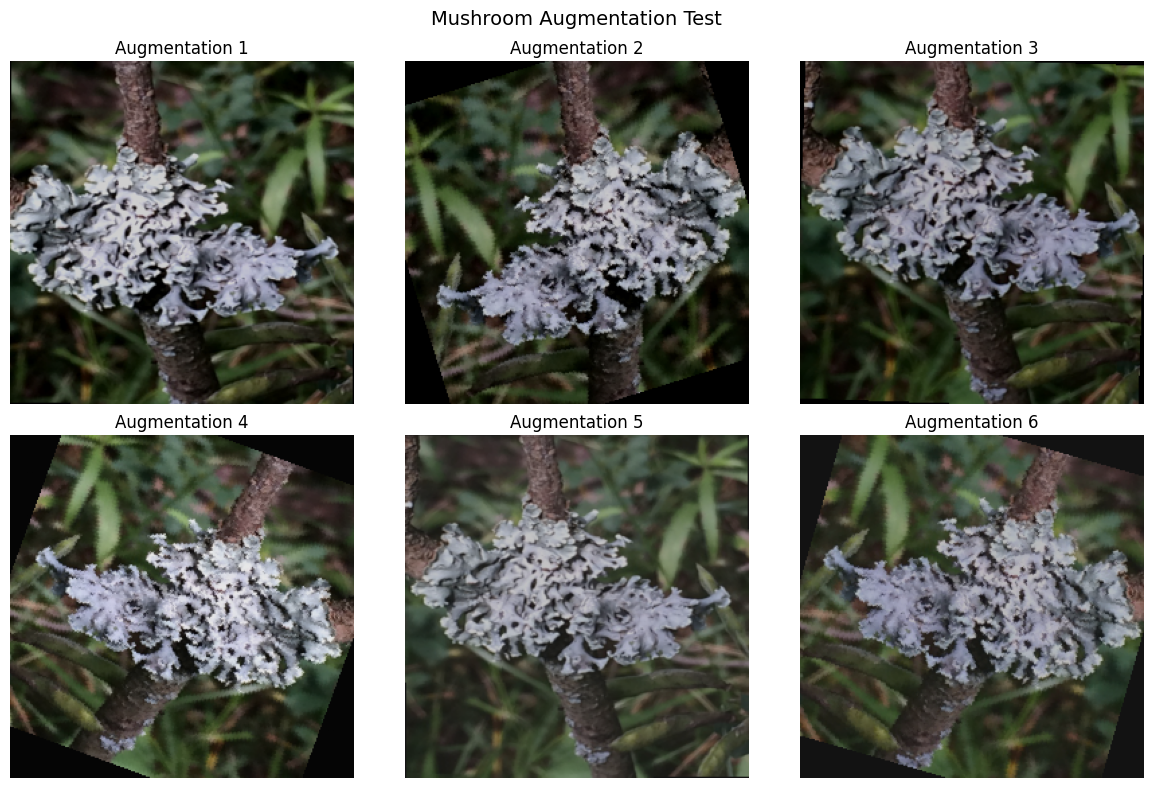

In [63]:
img_idx = 0
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i in range(12):
    image, label = dataset[img_idx]  # Now dataset exists!
    
    img_np = image.permute(1, 2, 0).numpy()
    img_np = np.clip(img_np, 0, 1)
    
    ax = axes[i//3, i%3]
    ax.imshow(img_np)
    ax.set_title(f"Augmentation {i+1}")
    ax.axis('off')

plt.suptitle("Mushroom Augmentation Test", fontsize=14)
plt.tight_layout()
plt.show()

In [64]:
# convert class_weights Series to list 
class_weights_list = class_weights.tolist() 

# create weighted sampler
sample_weights = []
for idx in range(len(dataset)):
    _, label = dataset[idx]
    weight = class_weights_list[label]  
    sample_weights.append(weight)

sampler = WeightedRandomSampler(sample_weights, len(sample_weights))

# create data loader
batch_size = 32
dataloader = DataLoader(dataset, batch_size=batch_size, sampler=sampler)

print(f"\nCreated dataset with {len(dataset)} samples")
print(f"Number of batches: {len(dataloader)}")

criterion = torch.nn.CrossEntropyLoss(
    weight=torch.tensor(class_weights_list, dtype=torch.float32) 
)


Created dataset with 6699 samples
Number of batches: 210


In [65]:
balanced_data.head()

,file_path,depth,file_name,file_ext,width,height,aspect_ratio,megapixels,orientation,class,species,phash,path_depth,species_fixed,species_fixed_final,species_norm,species_fixed_norm
7992,Classes/conditionally_edible/Hypogymnia physodes/28340medium.jpg,3,28340medium,jpg,375,500,0.750000,0.1875,portrait,conditionally_edible,Hypogymnia physodes,c6cf3b32d25ec882,4,Hypogymnia physodes,hypogymnia_physodes,hypogymnia_physodes,hypogymnia_physodes
54765,Classes/conditionally_edible/Graphis scripta/10525medium.jpeg,3,10525medium,jpeg,500,333,1.501502,0.1665,landscape,conditionally_edible,Graphis scripta,a9a55e077a107675,4,Graphis scripta,graphis_scripta,graphis_scripta,graphis_scripta
54228,Classes/conditionally_edible/Imleria badia/13362medium.jpg,3,13362medium,jpg,375,500,0.750000,0.1875,portrait,conditionally_edible,Imleria badia,db1130c9035e677d,4,Imleria badia,imleria_badia,imleria_badia,imleria_badia
4255,Classes/conditionally_edible/Fomitopsis pinicola/20128medium.jpeg,3,20128medium,jpeg,500,374,1.336898,0.1870,landscape,conditionally_edible,Fomitopsis pinicola,b07770b5e00fc333,4,Fomitopsis pinicola,fomitopsis_pinicola,fomitopsis_pinicola,fomitopsis_pinicola
17314,Classes/conditionally_edible/Phellinus tremulae/21957medium.jpg,3,21957medium,jpg,500,332,1.506024,0.1660,landscape,conditionally_edible,Phellinus tremulae,ab50acdd32aed324,4,Phellinus tremulae,phellinus_tremulae,phellinus_tremulae,phellinus_tremulae


In [66]:
def get_transformed_size(image_path, transform, num_samples=5):
    """Test transform multiple times to see output size variations"""
    image = Image.open(image_path).convert('RGB')
    sizes = []
    
    for _ in range(num_samples):
        transformed = transform(image)
        sizes.append((transformed.shape[2], transformed.shape[1]))  # (width, height)
    
    # Get most common size
    from collections import Counter
    size_counts = Counter(sizes)
    most_common = size_counts.most_common(1)[0][0]
    
    return most_common, sizes

# Test on first image
test_path = balanced_data.iloc[0]['file_path']
common_size, all_sizes = get_transformed_size(test_path, transform, num_samples=10)

print(f"Most common transformed size: {common_size[0]}×{common_size[1]}")
print(f"All observed sizes: {set(all_sizes)}")

# Add to dataframe
balanced_data['augmented_width'], balanced_data['augmented_height'] = common_size

Most common transformed size: 256×256
All observed sizes: {(256, 256)}


In [67]:
# Save balanced_data to CSV file
balanced_data.to_csv('mushrooms_balanced_dataset.csv', index=False)
print("Saved balanced dataset to: mushrooms_balanced_dataset.csv")
print(f"File contains {len(balanced_data)} rows and {len(balanced_data.columns)} columns")

Saved balanced dataset to: mushrooms_balanced_dataset.csv
File contains 6699 rows and 19 columns


In [68]:
# check the saved file
loaded_data = pd.read_csv('mushrooms_balanced_dataset.csv')
print(loaded_data['class'].value_counts())

class
conditionally_edible    2000
poisonous               2000
edible                  2000
deadly                   699
Name: count, dtype: int64


In [69]:
# Split 1: Set 80% train, 20% temp (val+test)
splitter = GroupShuffleSplit(test_size=0.2, random_state=42, n_splits=1)

# groups = balanced_data['species_fixed_final'] - ensures species don't overlap
for train_idx, temp_idx in splitter.split(balanced_data, groups=balanced_data['species_fixed_final']):
    train_data = balanced_data.iloc[train_idx]
    temp_data = balanced_data.iloc[temp_idx]

In [70]:
# Split 2: 75% val, 25% test (of the 20% = 15% val, 5% test overall)
splitter2 = GroupShuffleSplit(test_size=0.25, random_state=42, n_splits=1)

for val_idx, test_idx in splitter2.split(temp_data, groups=temp_data['species_fixed_final']):
    val_data = temp_data.iloc[val_idx]
    test_data = temp_data.iloc[test_idx]

In [71]:
print("Split by SPECIES GROUPS (NO species leakage)")
print(f"Train: {len(train_data)} samples, {train_data['species_fixed_final'].nunique()} species")
print(f"Val: {len(val_data)} samples, {val_data['species_fixed_final'].nunique()} species")
print(f"Test: {len(test_data)} samples, {test_data['species_fixed_final'].nunique()} species")

Split by SPECIES GROUPS (NO species leakage)
Train: 6086 samples, 77 species
Val: 365 samples, 15 species
Test: 248 samples, 5 species


In [72]:
# check if there are any overlapping species between train and test
train_species = set(train_data['species_fixed_final'].unique())
test_species = set(test_data['species_fixed_final'].unique())
overlap = train_species.intersection(test_species)

In [73]:
print(f"Species overlap check:")
print(f"Train has {len(train_species)} unique species")
print(f"Test has {len(test_species)} unique species")
print(f"Overlap between train and test: {len(overlap)} species")
print(f"Overlap species: {list(overlap)[:5] if overlap else 'None'}")

Species overlap check:
Train has 77 unique species
Test has 5 unique species
Overlap between train and test: 0 species
Overlap species: None


In [74]:
# Check class balance in each split
print("*****   Class distribution in splits:   *****")
for name, df in [('Training', train_data), ('Validation', val_data), ('Test', test_data)]:
    print(f"\n{name}:")
    print(df['class'].value_counts())

*****   Class distribution in splits:   *****

Training:
class
poisonous               1913
edible                  1765
conditionally_edible    1709
deadly                   699
Name: count, dtype: int64

Validation:
class
conditionally_edible    281
edible                   45
poisonous                39
Name: count, dtype: int64

Test:
class
edible                  190
poisonous                48
conditionally_edible     10
Name: count, dtype: int64


## Training & Validating

The model looks at the mushroom images and tries to learn patterns:
- Deadly mushrooms often have certain colors/shapes
- Edible mushrooms have different features

It makes guesses, checks if wrong, and adjusts its internal "knowledge"

### Key metrics:

- Loss decreases = Getting better at guessing (1.4 → 0.2 = good!)
- Accuracy increases = More correct predictions (25% → 85% = learning!)

In [85]:
# calculate class weight
class_counts = balanced_data['class'].value_counts().sort_index()
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()
class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)

print("Class weights for loss function:")
print(dict(zip(class_counts.index, class_weights)))

Class weights for loss function:
{'conditionally_edible': 0.170612643397608, 'deadly': 0.48816206980717597, 'edible': 0.170612643397608, 'poisonous': 0.170612643397608}


In [76]:
# model setup
from torchvision import models

# Updated syntax (no deprecation warnings)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)  # Fixed!
model.fc = nn.Linear(model.fc.in_features, 4)  # 4 mushroom classes

print(f"Model ready: {model.__class__.__name__}")
print(f"Output classes: {model.fc.out_features}")


Model ready: ResNet
Output classes: 4


In [77]:
# optimizer and loss setup
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

print(f"Loss function weights: {class_weights_tensor}")


Loss function weights: tensor([0.1706, 0.4882, 0.1706, 0.1706])


In [78]:
# check data loader
print(f"DataLoader ready:")
print(f"  Batches: {len(dataloader)}")
print(f"  Batch size: {dataloader.batch_size}")
print(f"  Total samples: {len(dataset)}")


DataLoader ready:
  Batches: 210
  Batch size: 32
  Total samples: 6699


In [79]:
# test one batch
print("Testing one batch...")
model.train()
images, labels = next(iter(dataloader))
print(f"  Batch images shape: {images.shape}")  # Should be [32, 3, 256, 256]
print(f"  Batch labels shape: {labels.shape}")  # Should be [32]


Testing one batch...
  Batch images shape: torch.Size([32, 3, 256, 256])
  Batch labels shape: torch.Size([32])


In [80]:
# Forward pass test
outputs = model(images)
print(f"Model outputs shape: {outputs.shape}")  # Should be [32, 4]
print(f"Loss: {criterion(outputs, labels).item():.4f}")

print("*****   READY FOR TRAINING!   *****")

Model outputs shape: torch.Size([32, 4])
Loss: 1.7919
*****   READY FOR TRAINING!   *****


In [81]:
# calculate class weights if not done
if 'class_weights_tensor' not in locals():
    class_counts = balanced_data['class'].value_counts().sort_index()
    class_weights = 1.0 / class_counts
    class_weights = class_weights / class_weights.sum()
    class_weights_tensor = torch.tensor(class_weights.values, dtype=torch.float32)

In [82]:
# model setup with updated syntax
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
model.fc = nn.Linear(model.fc.in_features, 4)

In [83]:
# training setup
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

In [84]:
# simple training loop
num_epochs = 3
print(f"Training for {num_epochs} epochs...")

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(dataloader):
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        running_loss += loss.item()
        
        if batch_idx % 10 == 0:
            batch_acc = 100 * (predicted == labels).sum().item() / labels.size(0)
            print(f"Epoch {epoch+1}, Batch {batch_idx}: Loss={loss.item():.4f}, Acc={batch_acc:.1f}%")
    
    epoch_loss = running_loss / len(dataloader)
    epoch_acc = 100 * correct / total
    print(f"Epoch {epoch+1} Complete: Avg Loss={epoch_loss:.4f}, Accuracy={epoch_acc:.1f}%\n")

print(f"{num_epochs}-epoch training complete!")

🧠 Training for 3 epochs...
Epoch 1, Batch 0: Loss=1.3221, Acc=25.0%
Epoch 1, Batch 10: Loss=0.9991, Acc=53.1%
Epoch 1, Batch 20: Loss=0.8463, Acc=53.1%
Epoch 1, Batch 30: Loss=1.2994, Acc=34.4%
Epoch 1, Batch 40: Loss=0.9600, Acc=46.9%
Epoch 1, Batch 50: Loss=1.0739, Acc=40.6%
Epoch 1, Batch 60: Loss=0.6280, Acc=62.5%
Epoch 1, Batch 70: Loss=1.0005, Acc=37.5%
Epoch 1, Batch 80: Loss=0.8240, Acc=46.9%
Epoch 1, Batch 90: Loss=0.7467, Acc=56.2%
Epoch 1, Batch 100: Loss=0.6545, Acc=68.8%
Epoch 1, Batch 110: Loss=0.8694, Acc=65.6%
Epoch 1, Batch 120: Loss=0.6197, Acc=59.4%
Epoch 1, Batch 130: Loss=0.6115, Acc=59.4%
Epoch 1, Batch 140: Loss=1.3644, Acc=43.8%
Epoch 1, Batch 150: Loss=0.8266, Acc=43.8%
Epoch 1, Batch 160: Loss=0.6826, Acc=62.5%
Epoch 1, Batch 170: Loss=0.3375, Acc=84.4%
Epoch 1, Batch 180: Loss=0.7598, Acc=59.4%
Epoch 1, Batch 190: Loss=0.8537, Acc=43.8%
Epoch 1, Batch 200: Loss=0.9013, Acc=59.4%
Epoch 1 Complete: Avg Loss=0.8514, Accuracy=54.7%

Epoch 2, Batch 0: Loss=0.7118,